# Vacinação contra COVID-19 por Município e Impacto nas Taxas de Internação

Disciplina: Linguagens de Programação
Professor: Alexandre Louzada
Aluno: André Luiz dos Santos Ferreira
Outubro de 2026

## 1. Introdução

A vacinação contra a COVID-19 começou no Brasil em 2021 e um dos principais argumentos para a vacinação em massa era diminuir os casos graves, que são os que levam a internação. Isso pesa diretamente nos hospitais e no custo do sistema de saúde.

Neste trabalho uso uma base simulada com 8 municípios do Sudeste entre 2021 e 2024, com população, número de pessoas vacinadas e internações por COVID-19 em cada ano. A ideia é ver se os dados mostram alguma relação entre vacinar mais e internar menos.

## 2. Definição do problema

Pergunta: os municípios e anos com maior cobertura vacinal tiveram menos internações por COVID-19?

Essa pergunta é relevante porque, se a relação existir, ela ajuda a justificar o investimento em campanhas de vacinação e mostra onde elas fazem mais falta. Se não aparecer, é sinal de que outros fatores estão pesando mais nas internações e precisam ser olhados.

Com base nisso um gestor de saúde poderia decidir em quais municípios reforçar campanhas de vacinação e onde é mais provável precisar de leitos.

## 3. KPIs

KPI principal: internações por 100 mil habitantes

`internacoes / populacao * 100000`

Escolhi esse porque os municípios têm tamanhos muito diferentes, então comparar o número absoluto de internações não faz sentido. Por 100 mil habitantes é o padrão usado em saúde pública.

KPI de apoio: cobertura vacinal (%)

`vacinados / populacao * 100`

É a variável que vou comparar com o KPI principal para ver se existe relação.

## 4. Aquisição dos dados

Os dados vêm do repositório do professor no GitHub (https://github.com/AlexandreLouzada/Dados-Simulados), arquivo `Simulacao_Vacinacao_COVID_Municipios_2021_2024.xlsx`. Fiz a leitura direto pela URL raw do arquivo, assim não precisa fazer upload no Colab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.2f}".format

In [2]:
url = "https://raw.githubusercontent.com/AlexandreLouzada/Dados-Simulados/main/Simulacao_Vacinacao_COVID_Municipios_2021_2024.xlsx"
df = pd.read_excel(url)
df.head(8)

,Município,Ano,População Estimada,Pessoas Vacinadas,Internações por COVID-19
0,São Paulo,2021,6723388,3552667,55384
1,São Paulo,2022,6723388,5498353,37426
2,São Paulo,2023,6723388,3159874,38148
3,São Paulo,2024,6723388,4259911,21131
4,Rio de Janeiro,2021,10826850,4486745,105662
5,Rio de Janeiro,2022,10826850,10639652,40045
6,Rio de Janeiro,2023,10826850,5708754,37539
7,Rio de Janeiro,2024,10826850,6636529,67105


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Município                 32 non-null     str  
 1   Ano                       32 non-null     int64
 2   População Estimada        32 non-null     int64
 3   Pessoas Vacinadas         32 non-null     int64
 4   Internações por COVID-19  32 non-null     int64
dtypes: int64(4), str(1)
memory usage: 1.4 KB


São 32 linhas (8 municípios x 4 anos) e 5 colunas:

- Município: nome da cidade
- Ano: de 2021 a 2024
- População Estimada: população usada como base
- Pessoas Vacinadas: quantidade de vacinados registrados no ano
- Internações por COVID-19: internações no ano

## 5. Limpeza e preparação dos dados

In [4]:
# nulos e duplicados
print(df.isnull().sum())
print("duplicados:", df.duplicated().sum())

Município                   0
Ano                         0
População Estimada          0
Pessoas Vacinadas           0
Internações por COVID-19    0
dtype: int64
duplicados: 0


Não tem valores nulos nem linhas duplicadas. Vou renomear as colunas para facilitar no código (sem acento e sem espaço) e garantir os tipos.

In [5]:
df = df.rename(columns={
    "Município": "municipio",
    "Ano": "ano",
    "População Estimada": "populacao",
    "Pessoas Vacinadas": "vacinados",
    "Internações por COVID-19": "internacoes",
})

df["municipio"] = df["municipio"].astype(str)
df[["ano", "populacao", "vacinados", "internacoes"]] = df[["ano", "populacao", "vacinados", "internacoes"]].astype(int)
df.dtypes

municipio        str
ano            int64
populacao      int64
vacinados      int64
internacoes    int64
dtype: object

In [6]:
# a populacao muda de um ano pro outro?
df.groupby("municipio")["populacao"].nunique()

municipio
Belo Horizonte    1
Campinas          1
Niterói           1
Rio de Janeiro    1
Serra             1
São Paulo         1
Uberlândia        1
Vitória           1
Name: populacao, dtype: int64

A população é a mesma nos 4 anos para todas as cidades, então a base usa uma estimativa fixa. Também dá para ver que os valores não batem com a realidade (Vitória aparecendo com mais de 11 milhões de habitantes, por exemplo), o que é esperado por ser uma base simulada. Vou considerar os números como estão.

Criando as variáveis dos KPIs:

In [7]:
df["cobertura"] = df["vacinados"] / df["populacao"] * 100
df["internacoes_100k"] = df["internacoes"] / df["populacao"] * 100000

df[df["cobertura"] > 100][["municipio", "ano", "populacao", "vacinados", "cobertura"]]

,municipio,ano,populacao,vacinados,cobertura
10,Belo Horizonte,2023,9995979,10811939,108.16
12,Vitória,2021,11104790,12084916,108.83
13,Vitória,2022,11104790,11126536,100.20
15,Vitória,2024,11104790,11765982,105.95
24,Uberlândia,2021,2958505,3036547,102.64
25,Uberlândia,2022,2958505,3092560,104.53
29,Serra,2022,8107313,8720864,107.57


7 registros têm cobertura acima de 100%, ou seja, mais vacinados do que habitantes. Na prática isso pode acontecer quando pessoas de outras cidades se vacinam no município ou quando o número conta doses e não pessoas, mas aqui é mais provável que seja inconsistência da simulação.

Não removi essas linhas porque são quase 1/4 da base. Criei uma coluna marcando esses casos e na análise testo a correlação com e sem eles.

Também criei uma faixa de cobertura para comparar grupos.

In [8]:
df["acima_100"] = df["cobertura"] > 100

df["faixa_cobertura"] = pd.cut(
    df["cobertura"],
    bins=[0, 60, 80, np.inf],
    labels=["até 60%", "60% a 80%", "acima de 80%"],
)

df = df.sort_values(["municipio", "ano"]).reset_index(drop=True)
df.head()

,municipio,ano,populacao,vacinados,internacoes,cobertura,internacoes_100k,acima_100,faixa_cobertura
0,Belo Horizonte,2021,9995979,4159763,61957,41.61,619.82,False,até 60%
1,Belo Horizonte,2022,9995979,6796292,23723,67.99,237.33,False,60% a 80%
2,Belo Horizonte,2023,9995979,10811939,38606,108.16,386.22,True,acima de 80%
3,Belo Horizonte,2024,9995979,4632381,69442,46.34,694.70,False,até 60%
4,Campinas,2021,11484121,7042403,31941,61.32,278.13,False,60% a 80%


## 6. Análise exploratória

In [9]:
df[["cobertura", "internacoes_100k"]].describe()

,cobertura,internacoes_100k
count,32.00,32.00
mean,72.21,521.92
std,23.23,216.72
min,41.44,210.61
25%,52.75,338.61
50%,65.67,558.22
75%,98.44,671.63
max,108.83,975.93


A cobertura média ficou em 72%, mas varia bastante (de 41% a 109%). As internações variam de 211 a 976 por 100 mil habitantes, com média de 522.

In [10]:
# media por ano
por_ano = df.groupby("ano")[["cobertura", "internacoes_100k"]].mean()
por_ano

,cobertura,internacoes_100k
ano,,
2021,67.40,677.88
2022,89.75,472.87
2023,65.09,375.66
2024,66.58,561.26


In [11]:
# tabela comparando vacinados e internacoes por municipio (media dos 4 anos)
tabela = df.groupby("municipio").agg(
    populacao=("populacao", "first"),
    vacinados_media=("vacinados", "mean"),
    internacoes_media=("internacoes", "mean"),
    cobertura_media=("cobertura", "mean"),
    internacoes_100k_media=("internacoes_100k", "mean"),
).sort_values("cobertura_media", ascending=False)

tabela

,populacao,vacinados_media,internacoes_media,cobertura_media,internacoes_100k_media
municipio,,,,,
Vitória,11104790,10730309.75,60490.25,96.63,544.72
Uberlândia,2958505,2393881.25,12545.50,80.92,424.05
Niterói,4455299,3355022.00,21780.25,75.30,488.86
Serra,8107313,6004173.25,40628.25,74.06,501.13
Belo Horizonte,9995979,6600093.75,48432.00,66.03,484.51
Rio de Janeiro,10826850,6867920.00,62587.75,63.43,578.08
São Paulo,6723388,4117701.25,38022.25,61.24,565.52
Campinas,11484121,6895328.25,67579.50,60.04,588.46


Uberlândia tem a segunda maior cobertura média e a menor taxa de internação. Já Campinas, São Paulo e Rio têm as menores coberturas e estão entre as maiores taxas. Vitória foge do padrão: tem a maior cobertura e mesmo assim uma taxa de internação alta.

In [12]:
# correlacao entre cobertura e internacoes
pearson = df["cobertura"].corr(df["internacoes_100k"])
spearman = df["cobertura"].corr(df["internacoes_100k"], method="spearman")

sem_inconsistentes = df[~df["acima_100"]]
pearson_sem = sem_inconsistentes["cobertura"].corr(sem_inconsistentes["internacoes_100k"])
spearman_sem = sem_inconsistentes["cobertura"].corr(sem_inconsistentes["internacoes_100k"], method="spearman")

print(f"Todos os registros (n={len(df)}): Pearson {pearson:.2f} | Spearman {spearman:.2f}")
print(f"Sem cobertura > 100% (n={len(sem_inconsistentes)}): Pearson {pearson_sem:.2f} | Spearman {spearman_sem:.2f}")

Todos os registros (n=32): Pearson -0.13 | Spearman -0.17
Sem cobertura > 100% (n=25): Pearson -0.36 | Spearman -0.45


In [13]:
# media de internacoes por faixa de cobertura
df.groupby("faixa_cobertura", observed=True)["internacoes_100k"].agg(["mean", "count"])

,mean,count
faixa_cobertura,,
até 60%,603.49,12
60% a 80%,381.32,9
acima de 80%,547.97,11


In [14]:
# correlacao dentro de cada municipio (4 anos cada)
corr_municipio = df.groupby("municipio")[["cobertura", "internacoes_100k"]].apply(
    lambda g: g["cobertura"].corr(g["internacoes_100k"])
).sort_values()

corr_municipio

municipio
Rio de Janeiro   -0.63
Belo Horizonte   -0.63
Campinas         -0.46
Niterói          -0.41
São Paulo        -0.31
Uberlândia        0.33
Serra             0.85
Vitória           0.87
dtype: float64

In [15]:
# a vacinacao do ano anterior explica melhor as internacoes do ano seguinte?
df["cobertura_ano_anterior"] = df.groupby("municipio")["cobertura"].shift(1)
print("Correlação com a cobertura do ano anterior:", round(df["cobertura_ano_anterior"].corr(df["internacoes_100k"]), 2))

Correlação com a cobertura do ano anterior: 0.01


## 7. Visualizações

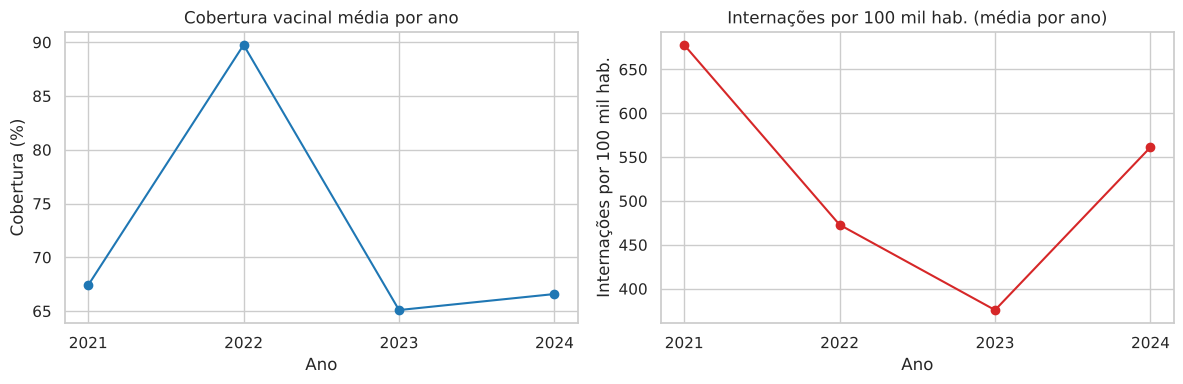

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(por_ano.index, por_ano["cobertura"], marker="o", color="tab:blue")
ax[0].set_title("Cobertura vacinal média por ano")
ax[0].set_xlabel("Ano")
ax[0].set_ylabel("Cobertura (%)")
ax[0].set_xticks(por_ano.index)

ax[1].plot(por_ano.index, por_ano["internacoes_100k"], marker="o", color="tab:red")
ax[1].set_title("Internações por 100 mil hab. (média por ano)")
ax[1].set_xlabel("Ano")
ax[1].set_ylabel("Internações por 100 mil hab.")
ax[1].set_xticks(por_ano.index)

plt.tight_layout()
plt.show()

2022 é o ano com maior cobertura (quase 90% em média) e as internações caem bastante em relação a 2021. Em 2023 a cobertura volta a cair e as internações continuam caindo, e em 2024 elas sobem de novo sem a cobertura ter mudado muito. Ou seja, no nível dos anos a relação aparece em 2022 mas não se mantém nos anos seguintes.

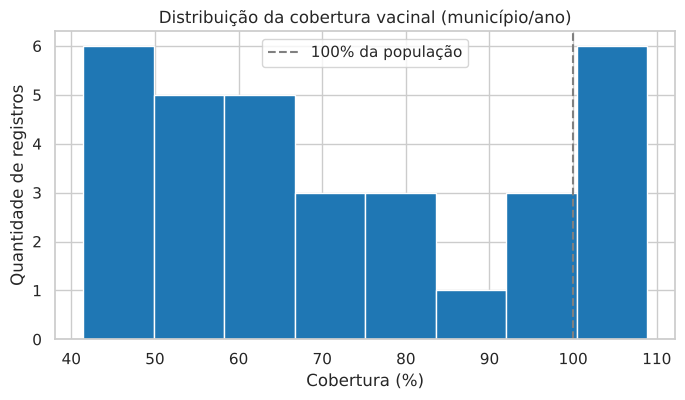

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(df["cobertura"], bins=8, color="tab:blue", edgecolor="white")
plt.axvline(100, color="gray", linestyle="--", label="100% da população")
plt.legend()
plt.title("Distribuição da cobertura vacinal (município/ano)")
plt.xlabel("Cobertura (%)")
plt.ylabel("Quantidade de registros")
plt.show()

A maioria dos registros fica abaixo de 80% de cobertura, mas tem um grupo separado acima de 100% (depois da linha tracejada) que são os casos inconsistentes que marquei na limpeza.

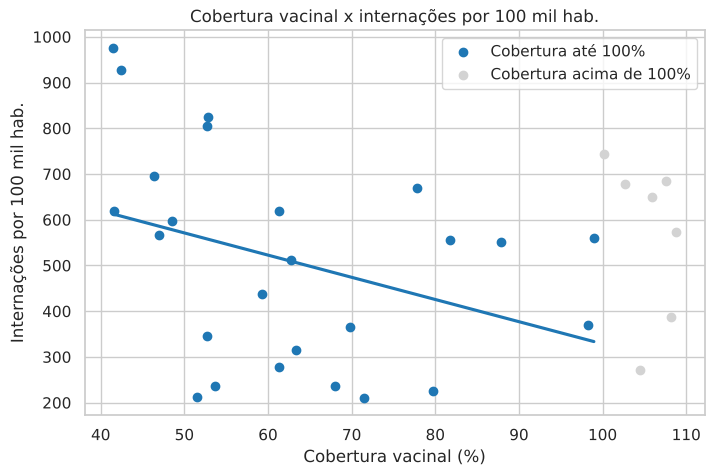

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(sem_inconsistentes["cobertura"], sem_inconsistentes["internacoes_100k"],
            color="tab:blue", label="Cobertura até 100%")
plt.scatter(df[df["acima_100"]]["cobertura"], df[df["acima_100"]]["internacoes_100k"],
            color="lightgray", label="Cobertura acima de 100%")
sns.regplot(data=sem_inconsistentes, x="cobertura", y="internacoes_100k",
            scatter=False, ci=None, color="tab:blue")
plt.title("Cobertura vacinal x internações por 100 mil hab.")
plt.xlabel("Cobertura vacinal (%)")
plt.ylabel("Internações por 100 mil hab.")
plt.legend()
plt.show()

Esse é o gráfico principal. Considerando só os registros com cobertura até 100% (em azul), a linha de tendência desce: quanto maior a cobertura, menor a taxa de internação. Mas os pontos estão bem espalhados em volta da linha, então a relação é moderada. Os pontos cinzas (acima de 100%) ficam com internações altas e puxam a correlação geral para quase zero.

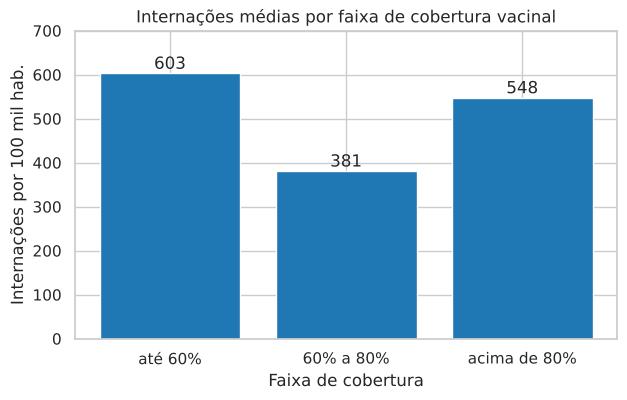

In [19]:
faixa = df.groupby("faixa_cobertura", observed=True)["internacoes_100k"].mean()

plt.figure(figsize=(7, 4))
plt.bar(faixa.index.astype(str), faixa.values, color="tab:blue")
plt.title("Internações médias por faixa de cobertura vacinal")
plt.xlabel("Faixa de cobertura")
plt.ylabel("Internações por 100 mil hab.")
for i, v in enumerate(faixa.values):
    plt.text(i, v + 10, f"{v:.0f}", ha="center")
plt.ylim(0, 700)
plt.show()

Os registros com cobertura entre 60% e 80% tiveram bem menos internações que os de até 60% (381 contra 603). A faixa acima de 80% volta a subir, mas é justamente a faixa onde estão os 7 registros acima de 100%, então esse resultado fica comprometido.

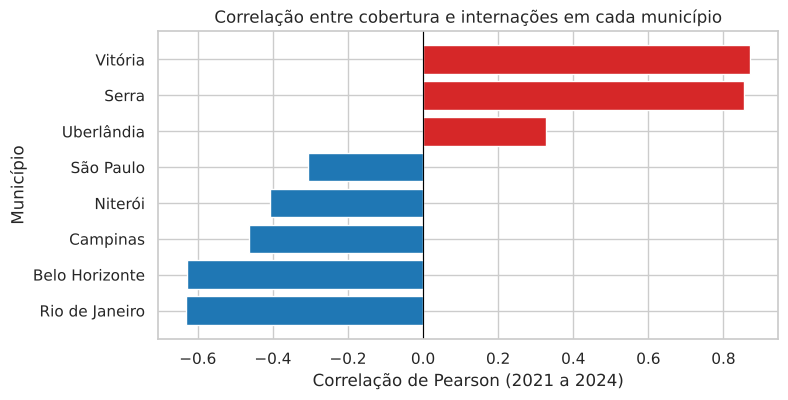

In [20]:
cores = ["tab:blue" if v < 0 else "tab:red" for v in corr_municipio.values]

plt.figure(figsize=(8, 4))
plt.barh(corr_municipio.index, corr_municipio.values, color=cores)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlação entre cobertura e internações em cada município")
plt.xlabel("Correlação de Pearson (2021 a 2024)")
plt.ylabel("Município")
plt.show()

Em 5 dos 8 municípios a correlação é negativa (mais vacina, menos internação), com destaque para Belo Horizonte e Rio de Janeiro. Vitória e Serra vão no sentido contrário, com correlação positiva forte, e Uberlândia tem uma correlação positiva fraca. Vale lembrar que cada município tem só 4 anos, então esses valores são bem sensíveis.

## 8. Insights e interpretação

Olhando a base inteira a correlação entre cobertura e internações é praticamente nula (-0,13). Só que esse número está sendo afetado pelos registros com cobertura acima de 100%, que são inconsistentes e têm internações altas. Tirando eles, a correlação passa para -0,36 (Pearson) e -0,45 (Spearman), o que já indica uma relação negativa moderada.

Algumas evidências que vão na direção de "vacinar mais reduz internação":
- 2022 teve a maior cobertura média e uma queda de cerca de 30% nas internações em relação a 2021.
- Registros com cobertura entre 60% e 80% tiveram em média 37% menos internações do que os com até 60%.
- Em 5 dos 8 municípios a correlação ao longo dos anos é negativa.
- Campinas teve sua maior taxa de internação (928 por 100 mil) em 2024, que foi o ano de menor cobertura dela (42%).

Mas tem coisas que não encaixam:
- Vitória e Serra têm correlação positiva forte, ou seja, nos anos em que vacinaram mais internaram mais.
- Em 2023 a cobertura média caiu e as internações continuaram caindo, e em 2024 elas subiram sem a cobertura ter mudado muito.
- Usar a cobertura do ano anterior não melhora nada (correlação perto de 0).

Limitações:
- A base é simulada, com população fixa e valores que não batem com a realidade.
- São só 32 observações, o que é pouco para tirar conclusões fortes.
- Não tem informação de dose (1ª, 2ª, reforço), faixa etária, variantes do vírus ou capacidade hospitalar, que influenciam muito as internações.
- Correlação não prova causa. Pode ser que cidades com mais internações tenham reagido vacinando mais, o que explicaria a correlação positiva em Vitória e Serra.

## 9. Conclusão

Respondendo à pergunta: existe uma relação negativa entre cobertura vacinal e internações nos dados, mas ela é moderada e não aparece em todos os municípios. Ela fica mais clara depois de tirar os registros inconsistentes (cobertura acima de 100%) e é mais forte em 2022, o ano com maior vacinação.

Com base nisso faria sentido manter a cobertura acima de 60% como meta mínima, já que abaixo disso estão as maiores taxas de internação, e olhar com mais atenção os municípios que fogem do padrão (Vitória, Serra e Campinas em 2024).

Para um próximo trabalho seria importante usar dados reais (DataSUS/OpenDataSUS), separar por dose e faixa etária e ter mais municípios, para ter uma amostra maior.

## 10. Reflexão final

Se fosse apresentar para um gestor, a mensagem principal seria: onde a cobertura vacinal ficou abaixo de 60% as internações foram as mais altas, e no ano em que a vacinação chegou mais perto de 90% as internações caíram cerca de 30%.

A ação seria manter as campanhas para não deixar a cobertura cair abaixo desse patamar e, antes de tomar decisões por município, corrigir os registros com mais vacinados do que habitantes, porque eles distorcem a análise e podem esconder onde a vacinação realmente está baixa.